In [1]:
from pydicom import dcmread
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from skimage.restoration import unwrap_phase
from einops import rearrange

In [2]:
B0_path = Path(r"scan_data\acdc_coil_basis_map_2026.04.27-09_18_26-DST-1.3.12.2.1107.5.99.3_19800101\STOCKMANN_Rev_D_Rev_D_shim_basis_mapping_20260427_091853~Study1")

dcm_ref_mag = dcmread(B0_path / 'gre_b0map_baseline_2_MR' / "1.dcm").pixel_array
dcm_ref_phs = dcmread(B0_path / 'gre_b0map_baseline_3_MR' / "1.dcm").pixel_array

dcm_fieldmap_pn = np.empty((2, 32, *dcm_ref_mag.shape), dtype=np.float32)
offset = 0
for ch in tqdm(range(32)):
    dcm_fieldmap_pn[0, ch] = dcmread(B0_path / f'gre_b0map_ch{ch}_p75_{ch*4+5+offset}_MR' / "1.dcm").pixel_array
    if ch*4+7 == 99:
        offset = 1
    dcm_fieldmap_pn[1, ch] = dcmread(B0_path / f'gre_b0map_ch{ch}_n75_{ch*4+7+offset}_MR' / "1.dcm").pixel_array
dcm_fieldmap_pn = (dcm_fieldmap_pn - 2048) / 4096 * 2 * np.pi

current_amplitude = 0.75 # A

  0%|          | 0/32 [00:00<?, ?it/s]

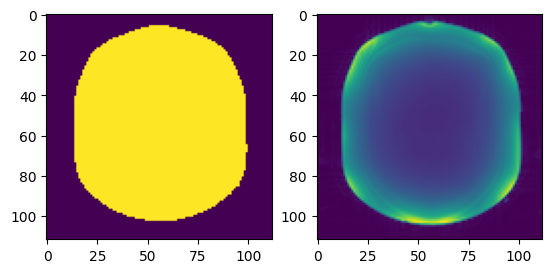

In [3]:
# erode the mask to avoid phase unwrapping errors at the edges
from scipy.ndimage import binary_erosion
mask = np.zeros_like(dcm_ref_mag, dtype=bool)
mask[dcm_ref_mag > 25] = True
mask = binary_erosion(mask, structure=np.ones((5,5,5), dtype=int))
slc = 64
plt.subplot(1,2,1)
plt.imshow(mask[slc,:,:])
plt.subplot(1,2,2)
plt.imshow(dcm_ref_mag[slc,:,:])

In [4]:
fieldmap_complex = (dcm_ref_mag[None, None].astype(np.complex64) * np.exp(1j * dcm_fieldmap_pn)).astype(np.complex64)
fieldmap_complex = ((fieldmap_complex[0] * fieldmap_complex[1].conj())*mask)
delta_TE = 2.46e-3
fieldmap_Hz = np.array([unwrap_phase(np.angle(fieldmap)) / (2*np.pi*delta_TE) for fieldmap in tqdm(fieldmap_complex, desc="Unwrapping Fieldmaps")])*mask
fieldmap_Hz = rearrange(fieldmap_Hz, 'ch z x y -> ch x y z') / (2 * current_amplitude)
data_mask = rearrange(mask, 'z x y -> x y z')
print(fieldmap_Hz.shape)

Unwrapping Fieldmaps:   0%|          | 0/32 [00:00<?, ?it/s]

(32, 112, 112, 112)


In [5]:
# extract spatial coordinate from the dicom header [3 x y z]
dcm_ref = dcmread(B0_path / 'gre_b0map_baseline_2_MR' / "1.dcm")
dcm_ref_mag = dcm_ref.pixel_array
def _get_shared_sequence_value(dcm, seq_name, item_name):
    if not hasattr(dcm, "SharedFunctionalGroupsSequence"):
        return None
    seq = getattr(dcm.SharedFunctionalGroupsSequence[0], seq_name, None)
    if seq is None:
        return None
    return getattr(seq[0], item_name, None)
def _get_per_frame_value(dcm, seq_name, item_name):
    if not hasattr(dcm, "PerFrameFunctionalGroupsSequence"):
        return None
    frame0 = dcm.PerFrameFunctionalGroupsSequence[0]
    seq = getattr(frame0, seq_name, None)
    if seq is None:
        return None
    return getattr(seq[0], item_name, None)
def _get_per_frame_positions(dcm):
    if not hasattr(dcm, "PerFrameFunctionalGroupsSequence"):
        return None
    positions = []
    for frame in dcm.PerFrameFunctionalGroupsSequence:
        if hasattr(frame, "PlanePositionSequence"):
            plane = frame.PlanePositionSequence[0]
            positions.append(np.array(plane.ImagePositionPatient, dtype=np.float32))
    if not positions:
        return None
    return np.stack(positions, axis=0)
def _get_iop(dcm):
    if hasattr(dcm, "ImageOrientationPatient"):
        return np.array(dcm.ImageOrientationPatient, dtype=np.float32)
    per_frame_iop = _get_per_frame_value(dcm, "PlaneOrientationSequence", "ImageOrientationPatient")
    if per_frame_iop is not None:
        return np.array(per_frame_iop, dtype=np.float32)
    shared_iop = _get_shared_sequence_value(dcm, "PlaneOrientationSequence", "ImageOrientationPatient")
    if shared_iop is not None:
        return np.array(shared_iop, dtype=np.float32)
    raise AttributeError("Missing ImageOrientationPatient")
def _get_ipp(dcm):
    if hasattr(dcm, "ImagePositionPatient"):
        return np.array(dcm.ImagePositionPatient, dtype=np.float32)
    per_frame_ipp = _get_per_frame_value(dcm, "PlanePositionSequence", "ImagePositionPatient")
    if per_frame_ipp is not None:
        return np.array(per_frame_ipp, dtype=np.float32)
    shared_ipp = _get_shared_sequence_value(dcm, "PlanePositionSequence", "ImagePositionPatient")
    if shared_ipp is not None:
        return np.array(shared_ipp, dtype=np.float32)
    raise AttributeError("Missing ImagePositionPatient")
def _get_spacing(dcm):
    if hasattr(dcm, "PixelSpacing"):
        spacing = np.array(dcm.PixelSpacing, dtype=np.float32)
        return float(spacing[0]), float(spacing[1])
    per_frame_spacing = _get_per_frame_value(dcm, "PixelMeasuresSequence", "PixelSpacing")
    if per_frame_spacing is not None:
        spacing = np.array(per_frame_spacing, dtype=np.float32)
        return float(spacing[0]), float(spacing[1])
    shared_spacing = _get_shared_sequence_value(dcm, "PixelMeasuresSequence", "PixelSpacing")
    if shared_spacing is None:
        raise AttributeError("Missing PixelSpacing")
    spacing = np.array(shared_spacing, dtype=np.float32)
    return float(spacing[0]), float(spacing[1])
def _get_slice_spacing(dcm):
    return float(getattr(dcm, "SpacingBetweenSlices", getattr(dcm, "SliceThickness", 1.0)))
def _voxel_coords_from_dicom(dcm, vol_shape):
    iop = _get_iop(dcm)
    row_cos = iop[:3]
    col_cos = iop[3:]
    slice_cos = np.cross(row_cos, col_cos)
    row_spacing, col_spacing = _get_spacing(dcm)
    positions = _get_per_frame_positions(dcm)
    if positions is not None and positions.shape[0] == vol_shape[0]:
        ipp0 = positions[0]
        if positions.shape[0] > 1:
            slice_spacing = float(np.linalg.norm(positions[1] - positions[0]))
        else:
            slice_spacing = _get_slice_spacing(dcm)
    else:
        ipp0 = _get_ipp(dcm)
        slice_spacing = _get_slice_spacing(dcm)
    x_idx = np.arange(vol_shape[2], dtype=np.float32)
    y_idx = np.arange(vol_shape[1], dtype=np.float32)
    z_idx = np.arange(vol_shape[0], dtype=np.float32)
    # zz, yy, xx = np.meshgrid(z_idx, y_idx, x_idx, indexing="ij")
    xx, yy, zz = np.meshgrid(x_idx, y_idx, z_idx, indexing="ij")
    coords = (
    ipp0[:, None, None, None]
    + col_cos[:, None, None, None] * (xx * col_spacing)
    + row_cos[:, None, None, None] * (yy * row_spacing)
    + slice_cos[:, None, None, None] * (zz * slice_spacing)
    )
    # coords shape: [3, z, y, x] with axis order matching dcm_ref_mag
    return coords
coords_xyz = _voxel_coords_from_dicom(dcm_ref, dcm_ref_mag.shape)
coords_xyz[1] *= -1  # flip y axis to match the image display
coords_xyz[2] *= -1  # flip z axis to match the image display
print("coords_xyz shape:", coords_xyz.shape)
print("x range:", coords_xyz[0].min(), coords_xyz[0].max())
print("y range:", coords_xyz[1].min(), coords_xyz[1].max())
print("z range:", coords_xyz[2].min(), coords_xyz[2].max())

coords_xyz shape: (3, 112, 112, 112)
x range: -112.0 110.0
y range: -110.0 112.0
z range: -91.0 131.0


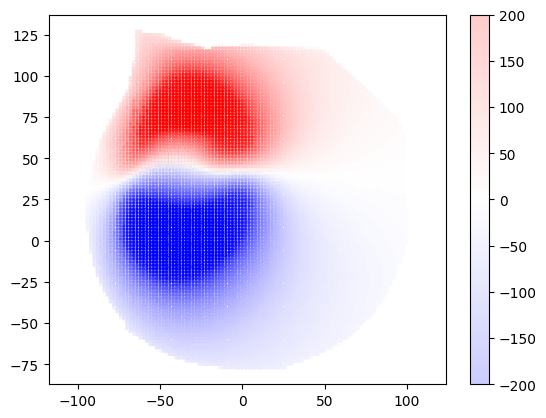

In [6]:
# plt.imshow(fieldmap_Hz[0,...,56], cmap='bwr')
# plt.imshow(data_mask[...,56], cmap='bwr')
plt.scatter(coords_xyz[1][data_mask], coords_xyz[2][data_mask], c=fieldmap_Hz[0][data_mask], s=2, cmap='bwr', alpha=0.2, vmin=-200, vmax=200)
plt.axis('equal')
# plt.clim(-500,500)
plt.colorbar()

C:\Users\bughh\AppData\Local\Temp\ipykernel_61228\1818475247.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


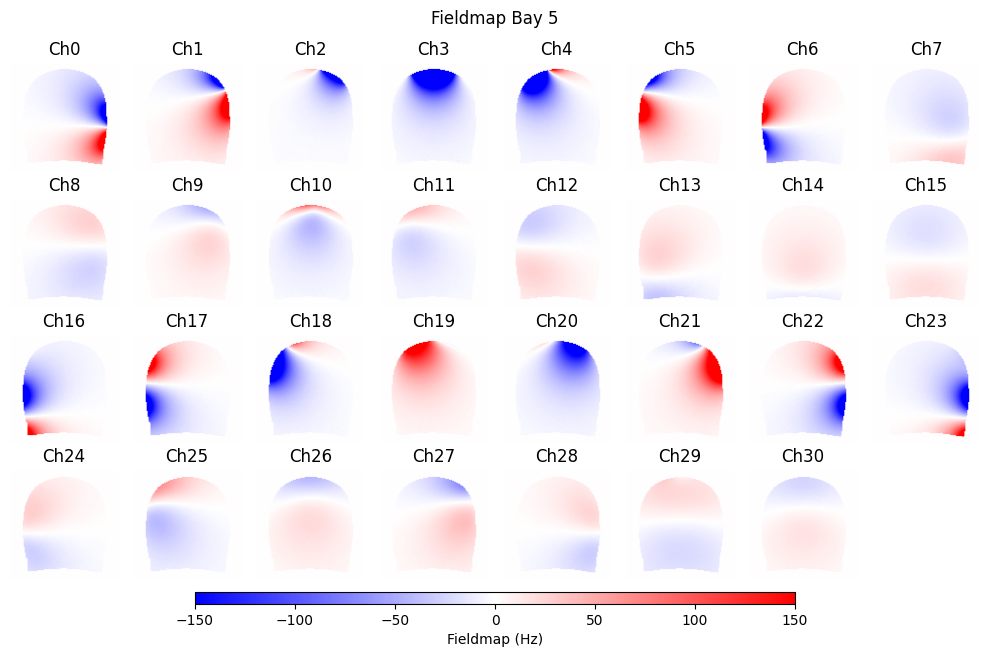

In [7]:
plt.figure(figsize=(10,6))
for i in range(31):
    plt.subplot(4, 8, i+1)
    plt.imshow(fieldmap_Hz[i,56,:,::-1].T, cmap='bwr')
    plt.xticks([])
    plt.clim(-150,150)
    plt.title(f"Ch{i}")
    plt.axis('off')
cbar_ax = plt.gcf().add_axes([0.2, -0.01, 0.6, 0.02])  # [left, bottom, width, height]
plt.colorbar(cax=cbar_ax, orientation='horizontal', label='Fieldmap (Hz)')
plt.suptitle("Fieldmap Bay 5")
plt.tight_layout()

In [8]:
# Save the fieldmap and corresponding coordinates for later use
np.savez("ACDC_fieldmap_data/fieldmap_bay5.npz", fieldmap_Hz=fieldmap_Hz[:-1], coords_xyz=coords_xyz, data_mask=data_mask)

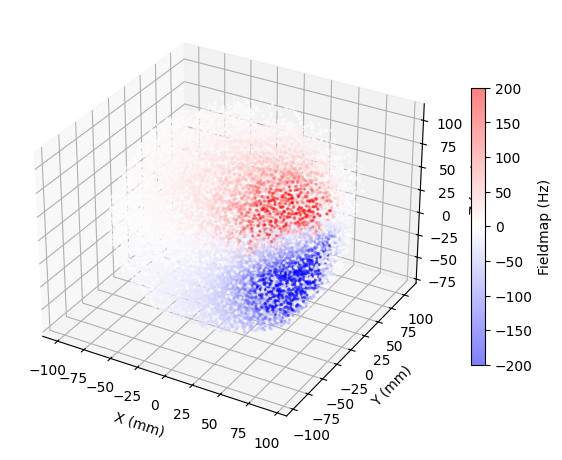

In [9]:
# 3D scatter for first channel to validate coordinates
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
sample_mask = mask & np.isfinite(fieldmap_Hz[13])
coords_flat = coords_xyz[:, sample_mask]
values_flat = fieldmap_Hz[0][sample_mask]
stride = max(coords_flat.shape[1] // 20000, 1)
coords_flat = coords_flat[:, ::stride]
values_flat = values_flat[::stride]
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(coords_flat[0], coords_flat[1], coords_flat[2], c=values_flat, s=2, cmap="bwr", alpha=0.5, vmin=-200, vmax=200)
ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")
fig.colorbar(sc, ax=ax, shrink=0.6, label="Fieldmap (Hz)")
plt.show()

In [10]:
print(dcm_ref_phs.max())

4095


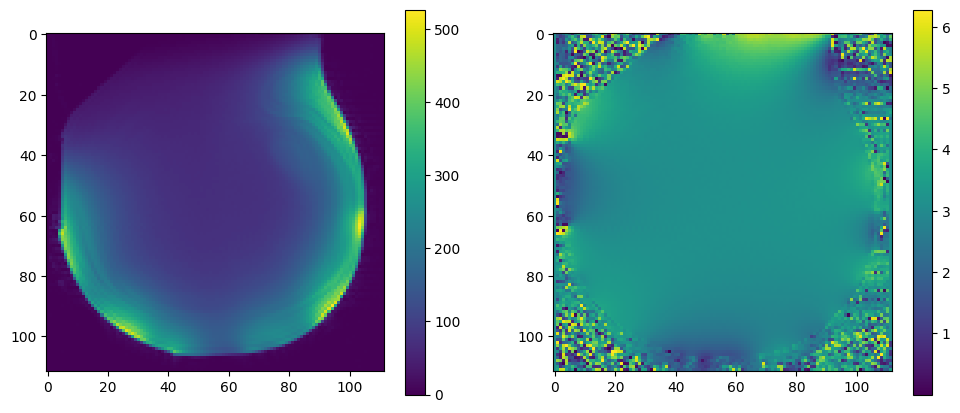

In [11]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(dcm_ref_mag[:,:,56])
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(dcm_ref_phs[:,:,56]/4096*2*np.pi)
plt.colorbar()
plt.show()
